In [ ]:
!wget -P data/trajectory_prediction https://huggingface.co/datasets/airvlab/guide3d/resolve/main/guide3d.zip
!unzip /content/data/trajectory_prediction/guide3d.zip -d data/trajectory_prediction/

In [ ]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/Guide3D
!cp -r /content/data/trajectory_prediction/guide3d /content/drive/MyDrive/Guide3D

Mounted at /content/drive
cp: cannot stat '/content/data/trajectory_prediction/guide3d': No such file or directory


In [ ]:
drive.mount('/content/drive')

# Download Dataset
!mkdir -p /content/data/trajectory_prediction/
!cp -r "/content/drive/MyDrive/Guide3D" /content/data/trajectory_prediction/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Mounted at /content/drive
Original Camera2 trajectory (first 5 frames):
[[514 298]
 [523 305]
 [528 317]
 [528 316]
 [529 319]]

Normalized Camera2 trajectory (first 5 frames):
[[0.2877095  0.13589744]
 [0.31284916 0.15384615]
 [0.32681564 0.18461538]
 [0.32681564 0.18205128]
 [0.32960894 0.18974359]]

Original Camera1 trajectory (first 5 frames):
[[578 305]
 [586 314]
 [600 323]
 [600 323]
 [600 324]]

Normalized Camera1 trajectory (first 5 frames):
[[0.30213904 0.12565445]
 [0.32352941 0.14921466]
 [0.36096257 0.17277487]
 [0.36096257 0.17277487]
 [0.36096257 0.17539267]]


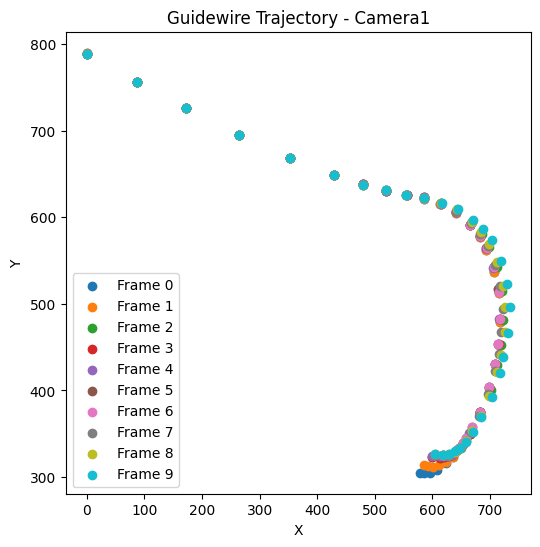

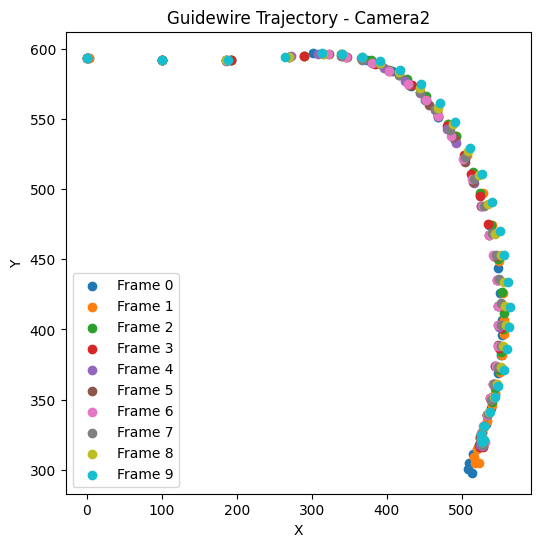

In [ ]:
# json_path="/content/data/trajectory_prediction/Guide3D/annotations/3d.json"
drive.mount('/content/drive')
json_path="/content/drive/MyDrive/Guide3D/annotations/3d.json"


# read JSON data
with open(json_path, 'r') as f:
    data = json.load(f)

# Load the data into array
# For the reason that JSON is a list, extract the data of first vedio
video_data = data[0]  # Extract data

# Extract all frames of video
frames = video_data["frames"]
frames = sorted(frames, key=lambda x: x["frame_number"])  # rank with frame_num

# Save the data
trajectories_camera2 = []
trajectories_camera1 = []
frame_numbers = []

for frame in frames:
    frame_numbers.append(frame["frame_number"])
    trajectories_camera2.append(frame["camera2"]["points"])  # Camera2
    trajectories_camera1.append(frame["camera1"]["points"])  # Camera1
    # # Choose camera2 or camera1
    # points = frame["camera2"]["points"]  # Choose which camera view
    # trajectories.append(points)

# Transform to numpy
MAX_POINTS = 30  # fixed length

# Cut the num of points in every frame
trajectories_camera2 = np.array([frame[:MAX_POINTS] for frame in trajectories_camera2])
trajectories_camera1 = np.array([frame[:MAX_POINTS] for frame in trajectories_camera1])


# Only take the first point to predict
guidewire_trajectory2 = trajectories_camera2[:, 0, :]  # (num_frames, 2)
guidewire_trajectory1 = trajectories_camera1[:, 0, :]

# Normalization
scaler = MinMaxScaler()
scaler_1 = MinMaxScaler()
guidewire_trajectory2_scaled = scaler.fit_transform(guidewire_trajectory2)
guidewire_trajectory1_scaled = scaler_1.fit_transform(guidewire_trajectory1)

# Compare the original data and normalized data
print("Original Camera2 trajectory (first 5 frames):")
print(guidewire_trajectory2[:5])
print("\nNormalized Camera2 trajectory (first 5 frames):")
print(guidewire_trajectory2_scaled[:5])

print("\nOriginal Camera1 trajectory (first 5 frames):")
print(guidewire_trajectory1[:5])
print("\nNormalized Camera1 trajectory (first 5 frames):")
print(guidewire_trajectory1_scaled[:5])

# for i in range(5):
#     print(f"Frame {frame_numbers[i]} - Camera2: {trajectories_camera2[i]}")
#     print(f"Frame {frame_numbers[i]} - Camera1: {trajectories_camera1[i]}")

# print Trajectory
plt.figure(figsize=(6, 6))
for i in range(10):
    x, y = zip(*trajectories_camera1[i])  # x, y coordinates
    plt.scatter(x, y, label=f"Frame {frame_numbers[i]}")
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Guidewire Trajectory - Camera1")
plt.show()

plt.figure(figsize=(6, 6))
for i in range(10):
    x, y = zip(*trajectories_camera2[i])  # x, y coordinates
    plt.scatter(x, y, label=f"Frame {frame_numbers[i]}")
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Guidewire Trajectory - Camera2")
plt.show()

In [ ]:
for i, frame in enumerate(trajectories_camera2):
    print(f"Frame {i}: {len(frame)} points")

Frame 0: 30 points
Frame 1: 30 points
Frame 2: 30 points
Frame 3: 30 points
Frame 4: 30 points
Frame 5: 30 points
Frame 6: 30 points
Frame 7: 30 points
Frame 8: 30 points
Frame 9: 30 points
Frame 10: 30 points
Frame 11: 30 points
Frame 12: 30 points
Frame 13: 30 points
Frame 14: 30 points
Frame 15: 30 points
Frame 16: 30 points
Frame 17: 30 points
Frame 18: 30 points
Frame 19: 30 points
Frame 20: 30 points
Frame 21: 30 points
Frame 22: 30 points
Frame 23: 30 points
Frame 24: 30 points
Frame 25: 30 points
Frame 26: 30 points
Frame 27: 30 points
Frame 28: 30 points
Frame 29: 30 points
Frame 30: 30 points
Frame 31: 30 points
Frame 32: 30 points
Frame 33: 30 points
Frame 34: 30 points
Frame 35: 30 points
Frame 36: 30 points
Frame 37: 30 points
Frame 38: 30 points
Frame 39: 30 points
Frame 40: 30 points
Frame 41: 30 points
Frame 42: 30 points
Frame 43: 30 points
Frame 44: 30 points
Frame 45: 30 points
Frame 46: 30 points
Frame 47: 30 points
Frame 48: 30 points
Frame 49: 30 points
Frame 50: 

In [ ]:
# 1
class LSTMModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, num_layers=2, output_size=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])  # output of last time step
        return out

In [ ]:
# Create LSTM training data (time-based window)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Data argumentation(shift, rotate, noise, scaling)(new added)
# def augment_trajectory(data, noise=0.5):
#     noisy_data = data + np.random.normal(0, noise, data.shape)  # add random noise
#     return np.vstack([data, noisy_data])


* Here are scripts for multi-point prediction. But for some reason the data type is incorrect so it will not be operated normally

In [ ]:
# 2
# Change the output range into 5
class MultiStepLSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, output_size=2, future_len=5):
        super(MultiStepLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, future_len * 2)  # Output coordinates of multiple points
        self.future_len = future_len

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]            # Only take the last step
        out = self.fc(out)     # output: (batch_size, future_len * 2)
        return out.view(-1, self.future_len, 2)  # reshape to
        return out


In [ ]:
# LSTM model for multiple points prediction
def create_multistep_sequences(data, past_len=10, future_len=5):
    X, y = [], []
    for i in range(len(data) - past_len - future_len + 1):
        X.append(data[i:i+past_len])
        y.append(data[i+past_len:i+past_len+future_len])
    return np.array(X), np.array(y)

* End of scripts for multi-point prediction

In [ ]:
# class CustomLSTM(nn.Module):
#     def __init__(self, input_size=2, hidden_size_x=96, hidden_size_y=64, num_layers_x=3, num_layers_y=2):
#         super(CustomLSTM, self).__init__()
#         self.hidden_size_x = hidden_size_x
#         self.hidden_size_y = hidden_size_y

#         # X-axis：Bidirectional LSTM
#         self.lstm_x = nn.LSTM(input_size=input_size, hidden_size=hidden_size_x, num_layers=num_layers_x, batch_first=True, bidirectional=False)
#         self.fc_x = nn.Linear(hidden_size_x, 1)

#         # Y-axis：单向 LSTM
#         self.lstm_y = nn.LSTM(input_size=input_size, hidden_size=hidden_size_y, num_layers=num_layers_y, batch_first=True, bidirectional=False)
#         self.fc_y = nn.Linear(hidden_size_y, 1)

#     def forward(self, x):
#         # deal with X-axis
#         x_out, _ = self.lstm_x(x)
#         x_pred = self.fc_x(x_out[:, -1, :])  # take the output of last time step

#         # deal with Y-axis
#         y_out, _ = self.lstm_y(x)
#         y_pred = self.fc_y(y_out[:, -1, :])

#         # combine results of X/Y prediction
#         return torch.cat((x_pred, y_pred), dim=1)

In [ ]:
# # Original structure

# # Initialization
# model = LSTMModel()
# criterion = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def custom_weighted_loss(y_pred, y_true, alpha=0.1):
    base_loss = criterion(y_pred, y_true)  # SmoothL1Loss
    final_loss = torch.mean(torch.norm(y_pred - y_true, dim=1))  # FDE
    return base_loss + alpha * final_loss

In [ ]:
# Original structure

# class LSTMModel(nn.Module):
#     def __init__(self, input_size=2, hidden_size=128, num_layers=2, output_size=2):
#         super(LSTMModel, self).__init__()
#         self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
#         self.fc = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         lstm_out, _ = self.lstm(x)
#         out = self.fc(lstm_out[:, -1, :])  # 取最后一个时间步的输出
#         return out

In [ ]:
# Clear temporary variable
X1, y1, X2, y2 = None, None, None, None
X_train_1 = X_val_1 = X_test_1 = None
y_train_1 = y_val_1 = y_test_1 = None
X_train_2 = X_val_2 = X_test_2 = None
y_train_2 = y_val_2 = y_test_2 = None


In [ ]:
# 1 Data pre-processing for basic LSTM model
SEQ_LENGTH = 10  # Use past 10 frames to predict future frame

X1, y1 = create_sequences(guidewire_trajectory1_scaled, SEQ_LENGTH)
X2, y2 = create_sequences(guidewire_trajectory2_scaled, SEQ_LENGTH)

* Start of scripts for multi-point prediction

In [ ]:
# 2 Data pre-processing for Multipoints-LSTM model
SEQ_LENGTH = 10  # Use past 10 frames to predict future frame
FUTURE_LENGTH = 5
X1, y1 = create_multistep_sequences(guidewire_trajectory1_scaled, SEQ_LENGTH, FUTURE_LENGTH)
X2, y2 = create_multistep_sequences(guidewire_trajectory2_scaled, SEQ_LENGTH, FUTURE_LENGTH)

* End of scripts for multi-point prediction

Train set: (377, 10, 2), Validation set: (93, 10, 2), Test set: (120, 10, 2)
Train set: (377, 10, 2), Validation set: (93, 10, 2), Test set: (120, 10, 2)
No. 10 group of Trajectory of tips (original) for Camera1:
[[0.65508021 0.4921466 ]
 [0.65508021 0.4921466 ]
 [0.67112299 0.44240838]
 [0.67112299 0.41361257]
 [0.66042781 0.41623037]
 [0.64438503 0.44764398]
 [0.63903743 0.47120419]
 [0.63903743 0.47120419]
 [0.63903743 0.48167539]
 [0.63903743 0.48167539]]


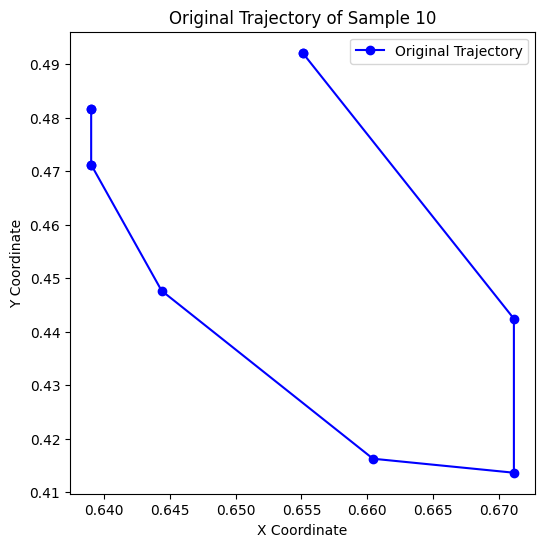

No. 10 group of Trajectory of tips (original) for Camera2:
[[0.85195531 0.48974359]
 [0.80446927 0.47435897]
 [0.75418994 0.45641026]
 [0.69832402 0.43333333]
 [0.65921788 0.44358974]
 [0.62849162 0.46153846]
 [0.60055866 0.48205128]
 [0.56703911 0.49230769]
 [0.53351955 0.5       ]
 [0.49441341 0.5025641 ]]


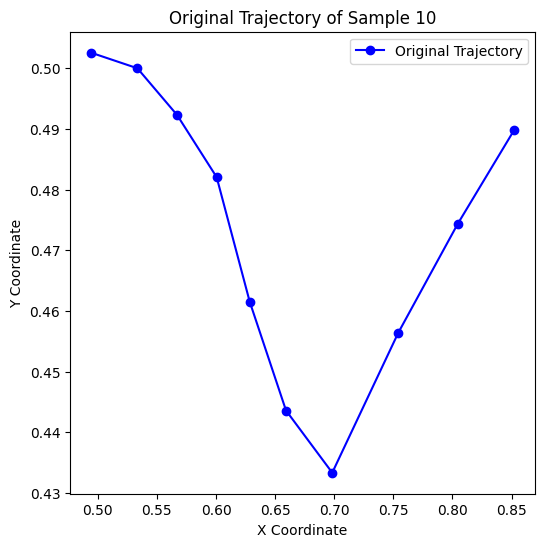

In [ ]:
# Train set（64%）, Validation set（16%）, Test set（20%）
# Use camera2 data for training first
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X1, y1, test_size=0.36, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.56, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X2, y2, test_size=0.36, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.56, random_state=42)

# Data argumentation
# X_train_1_augmented = augment_trajectory(X_train_1)
# y_train_1_augmented = augment_trajectory(y_train_1)

# Camera1 Transform to PyTorch tensor
X_train_1_torch = torch.tensor(X_train_1, dtype=torch.float32)
y_train_1_torch = torch.tensor(y_train_1, dtype=torch.float32)
# X_train_1_torch = torch.tensor(X_train_1_augmented, dtype=torch.float32)
# y_train_1_torch = torch.tensor(y_train_1_augmented, dtype=torch.float32)
X_val_1_torch = torch.tensor(X_val_1, dtype=torch.float32)
y_val_1_torch = torch.tensor(y_val_1, dtype=torch.float32)
X_test_1_torch = torch.tensor(X_test_1, dtype=torch.float32)
y_test_1_torch = torch.tensor(y_test_1, dtype=torch.float32)

# Camera2 Transform to PyTorch tensor
X_train_2_torch = torch.tensor(X_train_2, dtype=torch.float32)
y_train_2_torch = torch.tensor(y_train_2, dtype=torch.float32)
X_val_2_torch = torch.tensor(X_val_2, dtype=torch.float32)
y_val_2_torch = torch.tensor(y_val_2, dtype=torch.float32)
X_test_2_torch = torch.tensor(X_test_2, dtype=torch.float32)
y_test_2_torch = torch.tensor(y_test_2, dtype=torch.float32)

print(f"Train set: {X_train_1.shape}, Validation set: {X_val_1.shape}, Test set: {X_test_1.shape}")
print(f"Train set: {X_train_2.shape}, Validation set: {X_val_2.shape}, Test set: {X_test_2.shape}")

sample_index = 10  # Pick one sample
sample_trajectory_1 = X_train_1[sample_index, :, :]

print(f"No. {sample_index} group of Trajectory of tips (original) for Camera1:")
print(sample_trajectory_1)


plt.figure(figsize=(6, 6))
plt.plot(sample_trajectory_1[:, 0], sample_trajectory_1[:, 1], 'bo-', label="Original Trajectory")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title(f"Original Trajectory of Sample {sample_index}")
plt.legend()
plt.show()

sample_trajectory_2 = X_train_2[sample_index, :, :]

print(f"No. {sample_index} group of Trajectory of tips (original) for Camera2:")
print(sample_trajectory_2)


plt.figure(figsize=(6, 6))
plt.plot(sample_trajectory_2[:, 0], sample_trajectory_2[:, 1], 'bo-', label="Original Trajectory")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title(f"Original Trajectory of Sample {sample_index}")
plt.legend()
plt.show()


In [ ]:
# Initialization
model = LSTMModel()
# model = CustomLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120, eta_min=1e-5)


In [ ]:
EPOCHS = 600
BATCH_SIZE = 16
# EPOCHS = 600
# BATCH_SIZE = 16
PATIENCE = 50 # For early stopping checking
PATIENCE_lr = 10
best_val_loss = float('inf')  # Record minimum val_loss
patience_counter = 0  # Record how many continus rounds not be improved
min_train_val_gap = 0.0005

# Create DataLoader
train_loader_2 = torch.utils.data.DataLoader(list(zip(X_train_2_torch, y_train_2_torch)), batch_size=BATCH_SIZE, shuffle=True)
val_loader_2 = torch.utils.data.DataLoader(list(zip(X_val_2_torch, y_val_2_torch)), batch_size=BATCH_SIZE, shuffle=False)


for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader_2:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Calculate val_loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader_2:
            y_pred = model(batch_X)
            val_loss += criterion(y_pred, batch_y).item()

    train_loss /= len(train_loader_2)
    val_loss /= len(val_loader_2)
    # scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss  # Record new min val_loss
        patience_counter_lr = 0  # Re-count
        patience_counter = 0  # Re-count
        best_model = model.state_dict()  # Save best model

    else:
        patience_counter += 1  # Epoches not be optimized(continous) +1
        patience_counter_lr += 1

    if patience_counter_lr >= PATIENCE_lr and patience_counter_lr > 1e-5:
        scheduler.step(val_loss)

    if patience_counter >= PATIENCE:
      if abs(train_loss - val_loss) < min_train_val_gap:  # If Difference of Train Loss & Val Loss is small enough
        print(f"Early stopping triggered: Train Loss ({train_loss:.6f}) ≈ Val Loss ({val_loss:.6f})")
        print(f"Early stopping occured, it may stop training after {epoch+1} epoch（Optimal Val Loss: {best_val_loss:.6f}）")
        break  # Stop training
torch.save(best_model, 'lstm_camera2.pth')

Epoch 1/600, Train Loss: 0.100178, Val Loss: 0.047653
Epoch 2/600, Train Loss: 0.036956, Val Loss: 0.021571
Epoch 3/600, Train Loss: 0.022339, Val Loss: 0.014050
Epoch 4/600, Train Loss: 0.015704, Val Loss: 0.010118
Epoch 5/600, Train Loss: 0.013799, Val Loss: 0.008991
Epoch 6/600, Train Loss: 0.012949, Val Loss: 0.007464
Epoch 7/600, Train Loss: 0.011236, Val Loss: 0.006065
Epoch 8/600, Train Loss: 0.010070, Val Loss: 0.005329
Epoch 9/600, Train Loss: 0.008501, Val Loss: 0.004749
Epoch 10/600, Train Loss: 0.006899, Val Loss: 0.003670
Epoch 11/600, Train Loss: 0.006309, Val Loss: 0.002595
Epoch 12/600, Train Loss: 0.005319, Val Loss: 0.003673
Epoch 13/600, Train Loss: 0.004842, Val Loss: 0.002447
Epoch 14/600, Train Loss: 0.004133, Val Loss: 0.002144
Epoch 15/600, Train Loss: 0.004390, Val Loss: 0.002124
Epoch 16/600, Train Loss: 0.003991, Val Loss: 0.002806
Epoch 17/600, Train Loss: 0.003666, Val Loss: 0.001984
Epoch 18/600, Train Loss: 0.003631, Val Loss: 0.002351
Epoch 19/600, Train

X-axis MSE: 48.789871, Y-axis MSE: 124.362549, Fianl MSE: 86.576210
Hit Rate (threshold=5.0): 58.33%
Hit Rate (threshold=6.0): 65.83%
Hit Rate (threshold=7.0): 71.67%
Average Displacement Error (ADE): 6.93 px
Final Displacement Error (FDE): 6.45 px


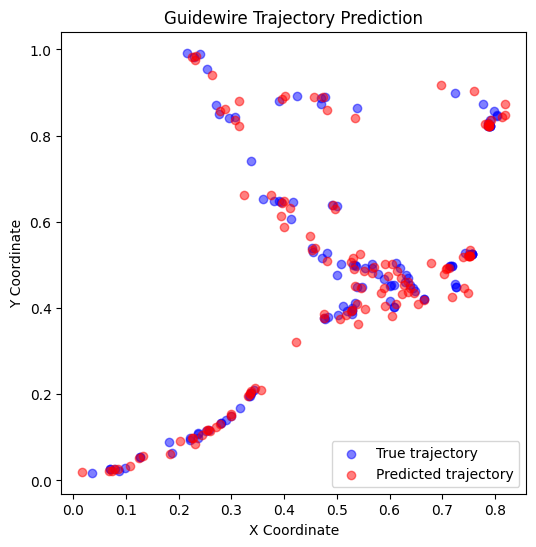

In [ ]:
# Model evaluation
model.eval()
with torch.no_grad():
    y_pred_2 = model(X_test_2_torch).numpy()
    y_test_2_np = y_test_2_torch.numpy()

# Reversed-normalization（recover to original coordinates）
y_pred_2_original = scaler.inverse_transform(y_pred_2)
y_test_2_original = scaler.inverse_transform(y_test_2_np)

# Calculate the loss
# mse = np.mean((y_pred_2_original - y_test_original) ** 2)
# print(f"mean square error (MSE): {mse:.6f}")
# Calculate MSE of each dimension
mse_x = np.mean((y_pred_2_original[:, 0] - y_test_2_original[:, 0]) ** 2)
mse_y = np.mean((y_pred_2_original[:, 1] - y_test_2_original[:, 1]) ** 2)

# Calculate entire MSE（Average of x & y）
mse_final = (mse_x + mse_y) / 2

print(f"X-axis MSE: {mse_x:.6f}, Y-axis MSE: {mse_y:.6f}, Fianl MSE: {mse_final:.6f}")

errors = np.sqrt(np.sum((y_pred_2_original - y_test_2_original) ** 2, axis=1))

for t in [5.0, 6.0, 7.0]: # Different threshold for hit rate
    hit = np.mean(errors < t) * 100
    print(f"Hit Rate (threshold={t}): {hit:.2f}%")

# ADE (Average displacement error) = average error of all points
ade = np.mean(errors)

# FDE (Final displacement error) = prediction error of last frame
fde = errors[-1]  # error of last trajectory

print(f"Average Displacement Error (ADE): {ade:.2f} px")
print(f"Final Displacement Error (FDE): {fde:.2f} px")

plt.figure(figsize=(6, 6))
plt.scatter(y_test_2_np[:, 0], y_test_2_np[:, 1], label="True trajectory", c="blue", alpha=0.5)
plt.scatter(y_pred_2[:, 0], y_pred_2[:, 1], label="Predicted trajectory", c="red", alpha=0.5)
plt.legend()
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Guidewire Trajectory Prediction")
plt.show()

In [ ]:
model = LSTMModel()
model.load_state_dict(torch.load('lstm_camera2.pth'))

# Freeze LSTM layer（before）
for param in model.lstm.parameters():
    param.requires_grad = False

# optimizer & loss
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
criterion = nn.SmoothL1Loss()  # smooth L1 Loss, more robust


# # Freeze LSTM, only use fc output
# for param in model.lstm.parameters():
#     param.requires_grad = False

# optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
# criterion = nn.MSELoss()



# Fine-tune Training
EPOCHS_MODIFY = 80
UNFREEZE_AT = 30  # The epoch that start unfreeze LSTM model
THRESHOLD = 5.0
train_loader_1 = torch.utils.data.DataLoader(list(zip(X_train_1_torch, y_train_1_torch)), batch_size=16, shuffle=True)
val_loader_1 = torch.utils.data.DataLoader(list(zip(X_val_1_torch, y_val_1_torch)), batch_size=16, shuffle=False)

for epoch in range(EPOCHS_MODIFY):

    if epoch == UNFREEZE_AT:
        for param in model.lstm.parameters():
            param.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=1e-5)  # Re-build optimizer

    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader_1:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        # loss = criterion(y_pred, batch_y)
        loss = custom_weighted_loss(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader_1:
            y_pred = model(batch_X)
            val_loss += criterion(y_pred, batch_y).item()

    train_loss /= len(train_loader_1)
    val_loss /= len(val_loader_1)

    print(f"Epoch {epoch+1}/{EPOCHS_MODIFY}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")




Epoch 1/80, Train Loss: 0.003338, Val Loss: 0.000382
Epoch 2/80, Train Loss: 0.003341, Val Loss: 0.000381
Epoch 3/80, Train Loss: 0.003373, Val Loss: 0.000381
Epoch 4/80, Train Loss: 0.003387, Val Loss: 0.000380
Epoch 5/80, Train Loss: 0.003301, Val Loss: 0.000380
Epoch 6/80, Train Loss: 0.003336, Val Loss: 0.000379
Epoch 7/80, Train Loss: 0.003317, Val Loss: 0.000379
Epoch 8/80, Train Loss: 0.003328, Val Loss: 0.000378
Epoch 9/80, Train Loss: 0.003315, Val Loss: 0.000378
Epoch 10/80, Train Loss: 0.003294, Val Loss: 0.000378
Epoch 11/80, Train Loss: 0.003322, Val Loss: 0.000377
Epoch 12/80, Train Loss: 0.003359, Val Loss: 0.000377
Epoch 13/80, Train Loss: 0.003311, Val Loss: 0.000377
Epoch 14/80, Train Loss: 0.003332, Val Loss: 0.000377
Epoch 15/80, Train Loss: 0.003282, Val Loss: 0.000376
Epoch 16/80, Train Loss: 0.003397, Val Loss: 0.000376
Epoch 17/80, Train Loss: 0.003434, Val Loss: 0.000376
Epoch 18/80, Train Loss: 0.003280, Val Loss: 0.000376
Epoch 19/80, Train Loss: 0.003385, Va

X MSE: 167.86, Y MSE: 101.54, Final MSE: 134.70
Hit Rate (threshold=5.0): 55.83%
Hit Rate (threshold=6.0): 66.67%
Hit Rate (threshold=7.0): 70.83%
Average Displacement Error (ADE): 8.07 px
Final Displacement Error (FDE): 17.66 px


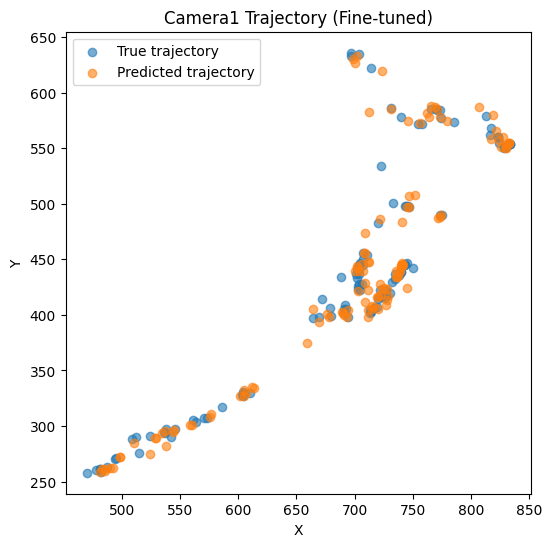

In [ ]:
# Evaluate Camera1 MSE & Hit Rate
model.eval()
with torch.no_grad():
    y_pred_1 = model(X_test_1_torch).numpy()
    y_test_1_np = y_test_1_torch.numpy()

# use scaler_1 inverse normalization
y_pred_1_original = scaler_1.inverse_transform(y_pred_1)
y_test_1_original = scaler_1.inverse_transform(y_test_1_np)

# evaluate
mse_x = np.mean((y_pred_1_original[:, 0] - y_test_1_original[:, 0]) ** 2)
mse_y = np.mean((y_pred_1_original[:, 1] - y_test_1_original[:, 1]) ** 2)
mse_final = (mse_x + mse_y) / 2
print(f"X MSE: {mse_x:.2f}, Y MSE: {mse_y:.2f}, Final MSE: {mse_final:.2f}")

# Hit Rate
errors = np.sqrt(np.sum((y_pred_1_original - y_test_1_original) ** 2, axis=1))
for t in [5.0, 6.0, 7.0]:
    hit = np.mean(errors < t) * 100
    print(f"Hit Rate (threshold={t}): {hit:.2f}%")

# ADE (Average Displacement Error) = average error of all points
ade = np.mean(errors)

# FDE (Final Displacement Error） = predict error of the last frame
fde = errors[-1]

print(f"Average Displacement Error (ADE): {ade:.2f} px")
print(f"Final Displacement Error (FDE): {fde:.2f} px")

# visible
plt.figure(figsize=(6, 6))
plt.scatter(y_test_1_original[:, 0], y_test_1_original[:, 1], label="True trajectory", alpha=0.6)
plt.scatter(y_pred_1_original[:, 0], y_pred_1_original[:, 1], label="Predicted trajectory", alpha=0.6)
plt.legend()
plt.title("Camera1 Trajectory (Fine-tuned)")
plt.xlabel("X"); plt.ylabel("Y")
plt.show()

In [ ]:
errors = np.sqrt(np.sum((y_pred_1_original - y_test_1_original) ** 2, axis=1))
THRESHOLD = 5.0  # Define error within 5 pixels is correct
hit_rate = np.mean(errors < THRESHOLD) * 100
print(f"Hit Rate of prediction(= recall): {hit_rate:.2f}%")

In [ ]:
# rmse_x = np.sqrt(np.mean((y_pred_original[:, 0] - y_test_original[:, 0]) ** 2))
# rmse_y = np.sqrt(np.mean((y_pred_original[:, 1] - y_test_original[:, 1]) ** 2))
# rmse_final = (rmse_x + rmse_y) / 2

# print(f"X-axis RMSE: {rmse_x:.6f}, Y-axis RMSE: {rmse_y:.6f}, Final RMSE: {rmse_final:.6f}")

In [ ]:
# # Calcualte error of X-axis & Y-axis
# errors_x = np.abs(y_pred_original[:, 0] - y_test_original[:, 0])
# errors_y = np.abs(y_pred_original[:, 1] - y_test_original[:, 1])

# # Allow error in X-axis / Y-axis seperatly, but still acceptable
# THRESHOLD_X = 5.0
# THRESHOLD_Y = 5.0

# hit_rate_x = np.mean(errors_x < THRESHOLD_X) * 100
# hit_rate_y = np.mean(errors_y < THRESHOLD_Y) * 100
# hit_rate_combined = np.mean((errors_x < THRESHOLD_X) & (errors_y < THRESHOLD_Y)) * 100

# print(f"Hit Rate (X-axis): {hit_rate_x:.2f}%")
# print(f"Hit Rate (Y-axis): {hit_rate_y:.2f}%")
# print(f"Final Hit Rate: {hit_rate_combined:.2f}%")


In [ ]:
true_positive = np.sum(errors < THRESHOLD)  # Correct prediction
false_negative = np.sum(errors >= THRESHOLD)  # Wrong prediction

recall = true_positive / (true_positive + false_negative) * 100
print(f"Recall: {recall:.2f}%")


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


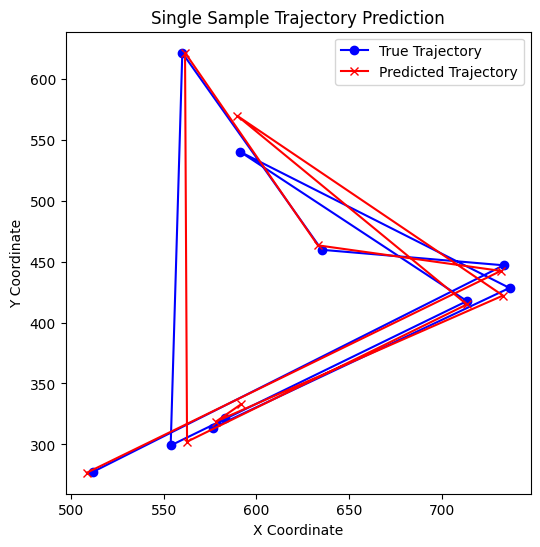

In [ ]:
sample_index = 10  # Choose one simple
sample_trajectory = y_test_original[sample_index * SEQ_LENGTH: (sample_index + 1) * SEQ_LENGTH]
sample_prediction = y_pred_original[sample_index * SEQ_LENGTH: (sample_index + 1) * SEQ_LENGTH]
print(frame_numbers[:10])  # Print frame_number of first 10 frame frame_number (increased)


plt.figure(figsize=(6, 6))
plt.plot(sample_trajectory[:, 0], sample_trajectory[:, 1], color='blue', marker='o', label="True Trajectory")
plt.plot(sample_prediction[:, 0], sample_prediction[:, 1], color='red', marker='x', label="Predicted Trajectory")
plt.legend()
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Single Sample Trajectory Prediction")
plt.show()
